In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

df=pd.read_csv("economic_index.csv")
df.tail()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
19,19,2016,5,1.75,6.1,866
20,20,2016,4,1.75,5.9,876
21,21,2016,3,1.75,6.2,822
22,22,2016,2,1.75,6.2,704
23,23,2016,1,1.75,6.1,719


In [2]:
df.drop(['Unnamed: 0','year','month'], axis=1, inplace=True)

In [3]:
df.tail()

,interest_rate,unemployment_rate,index_price
19,1.75,6.1,866
20,1.75,5.9,876
21,1.75,6.2,822
22,1.75,6.2,704
23,1.75,6.1,719


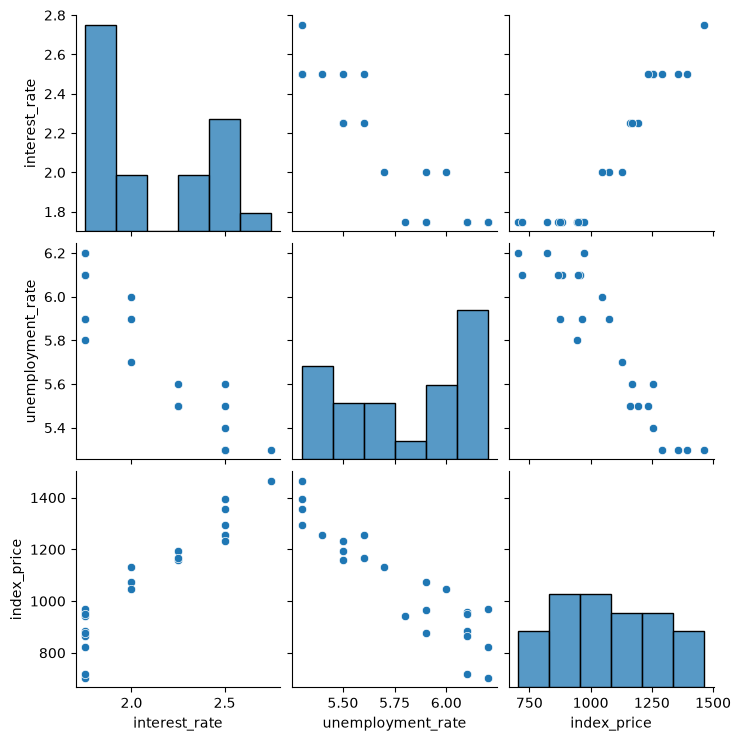

In [5]:
import seaborn as sns
sns.pairplot(df)

In [7]:
#independent and dependent variables
X=df.iloc[:,:-1]
y=df.iloc[:,-1]



In [9]:
#split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
#standardize
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [14]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print(model.coef_)
print(model.intercept_)

[  88.27275507 -116.25716066]
1053.4444444444443


In [18]:
#cross validation
from sklearn.model_selection import cross_val_score
Val_score=cross_val_score(model,x_train,y_train,cv=3,scoring='neg_mean_squared_error')
Val_score=np.mean(Val_score)
print(Val_score)

-5914.828180162388


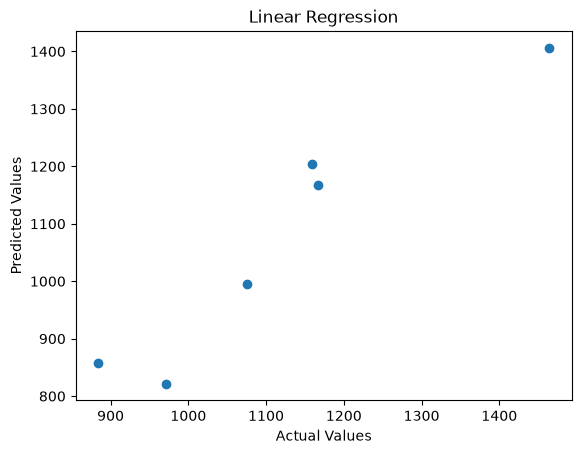

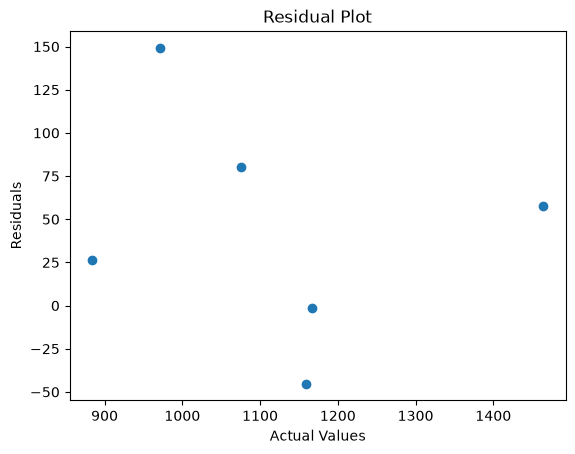

C:\Users\prakh\AppData\Local\Temp\ipykernel_19180\2094130553.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residiual)


<Axes: xlabel='index_price', ylabel='Density'>

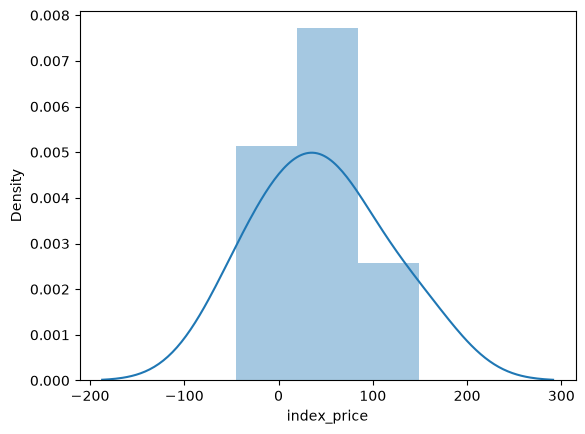

In [26]:
#prediction
y_prd=model.predict(x_test)
residiual=y_test-y_prd

plt.scatter(y_test,y_prd)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression')
plt.show()
plt.scatter(y_test,residiual)
plt.xlabel('Actual Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
sns.distplot(residiual)


In [ ]:
import statsmodels.api as sm
model=sm.OLS(y_train,x_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 09 Aug 2026   Prob (F-statistic):                       0.754
Time:                        17:03:06   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [44]:
model.predict(scaler.transform([[ 1.8, 6.8]]))

d:\Data Science\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-435.12733316])